## 1. Data Loading


In [1]:
#import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,roc_curve, roc_auc_score
data=pd.read_csv("data/creditcard.csv")

## 2. Data Understanding

In [2]:
print(data.head())
print(data.shape)
print(data.info())
print(data['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## 3. Exploratory Data Analysis (EDA)

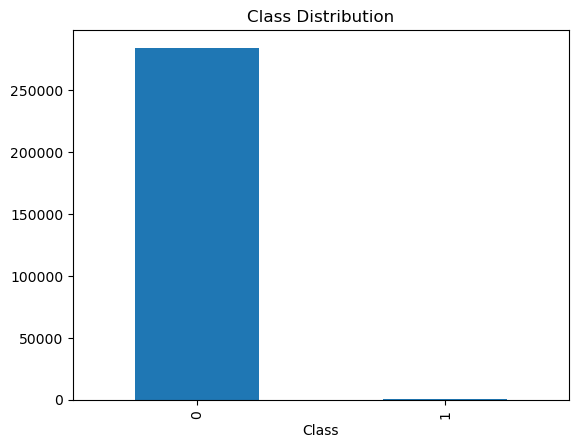

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


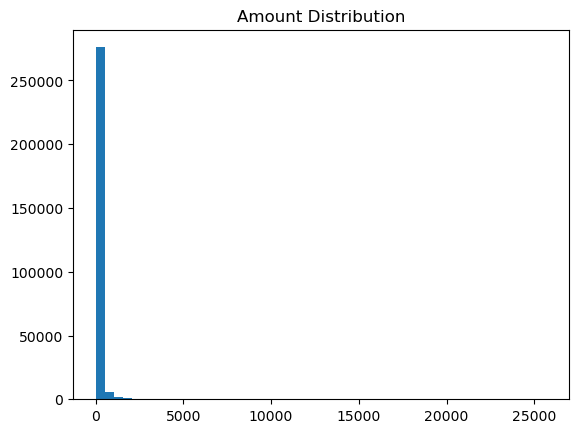

In [3]:
#Class Distribution
data["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()
print(data["Amount"].describe())
#Amount Distribution
plt.hist(data["Amount"], bins=50)
plt.title("Amount Distribution")
plt.show()

## 4. Feature Engineering

In [4]:
data["is_high_amount"] = (data["Amount"] > data["Amount"].quantile(0.95)).astype(int)

## 5. Model Training

In [5]:
#Data spliting
y=data['Class']
X=data.drop("Class", axis=1)
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#Scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Model Training
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)
#Predict Probabilities
probs = model.predict_proba(X_test_scaled)

## 6. ROC & AUC Evaluation

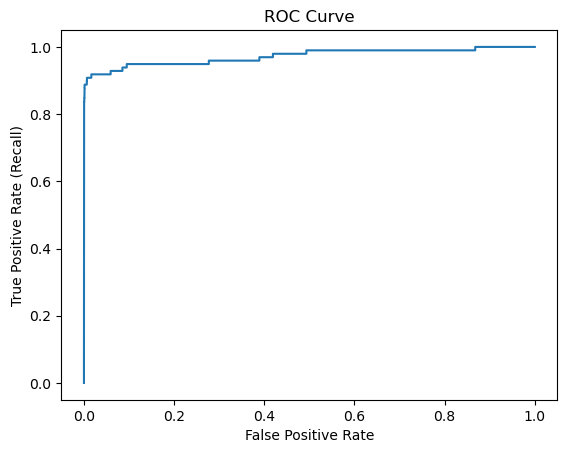

AUC: 0.9721109550319846


In [6]:
fpr, tpr, thresholds = roc_curve(y_test, probs[:,1])
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.show()
print("AUC:", roc_auc_score(y_test, probs[:,1]))

## 7. Threshold Tuning

In [7]:
for t in [0.9, 0.97, 0.98, 0.99]:
    y_pred = (probs[:,1] >= t).astype(int)
    print(f"Threshold {t}")
    print(classification_report(y_test, y_pred))

Threshold 0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.25      0.89      0.39        98

    accuracy                           1.00     56962
   macro avg       0.63      0.94      0.69     56962
weighted avg       1.00      1.00      1.00     56962

Threshold 0.97
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.89      0.64        98

    accuracy                           1.00     56962
   macro avg       0.75      0.94      0.82     56962
weighted avg       1.00      1.00      1.00     56962

Threshold 0.98
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.54      0.87      0.66        98

    accuracy                           1.00     56962
   macro avg       0.77      0.93      0.83     56962
weighted avg       1.00      1

## 8. Cost-Based Optimization

In [9]:
# Final threshold selected based on cost optimization
# balancing fraud detection (recall) and false alerts (precision)
#Cost-Based Threshold Function
def choose_best_threshold(probs, y_true, cost_fn=100, cost_fp=5): 
    thresholds = np.linspace(0.8, 1, 100)
    costs = []
    for t in thresholds:
        y_pred = (probs[:,1] >= t).astype(int)
        
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        cost = (fn * cost_fn) + (fp * cost_fp)
        costs.append(cost)
    best_idx = np.argmin(costs)
    return thresholds[best_idx],min(costs)
# choose Threshold
best_threshold,min_cost = choose_best_threshold(probs, y_test)
print("Best Threshold:{}, min_cost:{}".format( best_threshold,min_cost))

Best Threshold:0.9717171717171718, min_cost:1515


## 9. Final Evaluation

In [10]:
#Final Predictions
y_pred_final = (probs[:,1] >= best_threshold).astype(int)
#Evaluation
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.89      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.82     56962
weighted avg       1.00      1.00      1.00     56962



## 10. Save Model + Scaler

In [11]:
import joblib

joblib.dump(model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']